# 2D Polynomial Sky Subtraction — JWST MIRI F1000W i2d Mosaics

Removes residual large-scale background gradient from Stage 3 mosaics
by fitting a low-order 2D polynomial to the background (masking science regions).

**Input:** `miri_F1000W_final_i2d.fits` (output of `F1000W_pipeline.ipynb`)

**Output:** `miri_F1000W_final_i2d_skysub.fits` (sky-subtracted mosaic + SKYMODEL + SKYMASK extensions)

## 1. Configuration

In [1]:
# ═══════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════

FILT           = 'F1000W'
BASE_DIR       = '/Users/melyajou/SMC_GO5952/miri'
STAGE3_DIR     = f'{BASE_DIR}/{FILT}/stage3'
fig_dir        = f"{BASE_DIR}/{FILT}/figures"


# Input files
INPUT_FILE     = f'{STAGE3_DIR}/miri_{FILT}_final_i2d.fits'
SEGM_FILE      = f'{STAGE3_DIR}/miri_{FILT}_final_segm.fits'
BKG_BASE       = f"{BASE_DIR}/{FILT}/MAST_2026-03-12T1713/JWST"
OUTPUT_FILE    = None   # None = auto-generate as *_skysub.fits

# Polynomial fit
POLY_DEGREE    = 2      # 2 = quadratic, 3 = cubic
EDGE_CROP      = 50   # mask this many pixels from edges of valid data
# Source masking
SIGMA_UPPER    = 2    # 1.7 mask pixels > this many σ above background
GROW_NPIX      = 10      # grow mask by N pixels to catch source wings

# Plotting
CMAP           = 'afmhot'
FIG_DPI        = 200

## 2. Setup

In [2]:
import sys, os
import glob
from jwst import datamodels
from astropy.stats import sigma_clipped_stats
sys.path.insert(0, '..')
from skysub_utils import *
from pipeline_utils import load_mosaic, plot_mosaic, get_stats, stats_label

import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

## 3. Load the i2d mosaic

In [3]:
hdul = fits.open(INPUT_FILE)
hdul.info()

Filename: /Users/melyajou/SMC_GO5952/miri/F1000W/stage3/miri_F1000W_final_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     257   ()      
  1  SCI           1 ImageHDU        75   (1794, 1184)   float32   
  2  ERR           1 ImageHDU        10   (1794, 1184)   float32   
  3  CON           1 ImageHDU        10   (1794, 1184, 1)   int32   
  4  WHT           1 ImageHDU         9   (1794, 1184)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (1794, 1184)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (1794, 1184)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (1794, 1184)   float32   
  8  HDRTAB        1 BinTableHDU    494   8R x 242C   [23A, 5A, 3A, 59A, 7A, 13A, 4A, 5A, 6A, 7A, 10A, 4A, L, D, D, 4A, 22A, 67A, 28A, 2A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 12A, 4A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 12A, 12A, 5A, D, D, D, D, D, D, D, D, 4A, 8A, 6A, 4A, 3A, 4A, K, 5A, 9A, D, D,

In [4]:
# Extract science data
if 'SCI' in [h.name for h in hdul]:
    data = hdul['SCI'].data.copy()
    header = hdul['SCI'].header.copy()
else:
    data = hdul[0].data.copy()
    header = hdul[0].header.copy()

print(f'Image shape: {data.shape}')
print(f'Data range:  [{np.nanmin(data):.4f}, {np.nanmax(data):.4f}]')

Image shape: (1184, 1794)
Data range:  [11.3651, 559.8335]


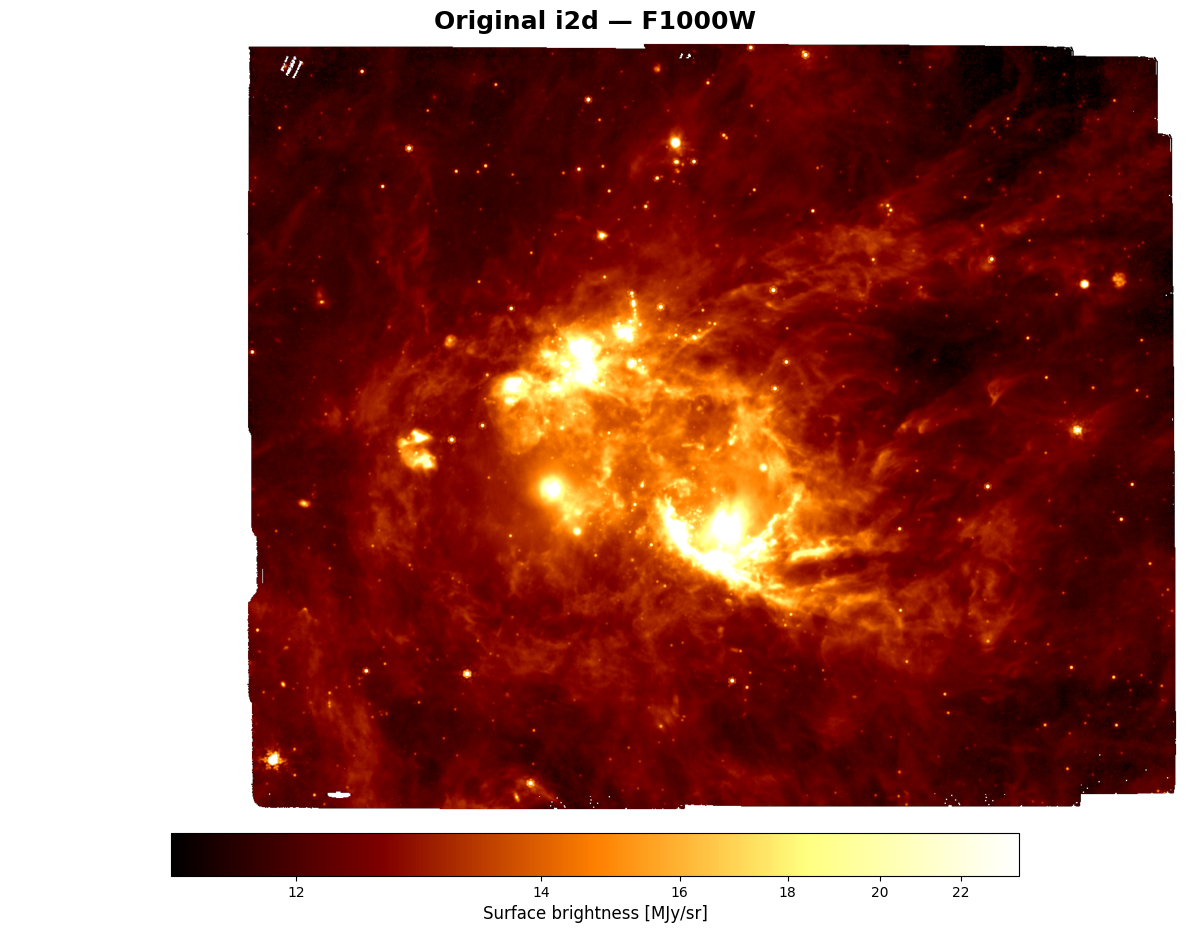

In [5]:
# Quick look
fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')
norm = simple_norm(data, 'sqrt', percent=99)
im = ax.imshow(data, cmap=CMAP, origin='lower', norm=norm)
ax.set_title(f'Original i2d — {FILT}', fontsize=18, fontweight='bold', pad=10)
ax.axis('off')
cb = plt.colorbar(im, ax=ax, orientation='horizontal',
                  fraction=0.046, pad=0.02, shrink=0.85)
cb.set_label('Surface brightness [MJy/sr]', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Source Masking

Three layers of masking (combined):
1. **Segmentation map** — masks detected compact sources from the catalog
2. **Sigma clipping** — catches extended diffuse emission not in the segmentation map
3. **Dilation** — grows the mask to catch source wings

The polynomial is fit only to the unmasked (background) pixels.

In [6]:
mask, mean_bg, std_bg = make_source_mask(
    data, segm_file=SEGM_FILE, nsigma=SIGMA_UPPER, grow_npix=GROW_NPIX
)
# Mask edges of the mosaic
if EDGE_CROP > 0:
    # Find the valid data region
    valid = ~np.isnan(data) & (data != 0)
    from scipy.ndimage import binary_erosion
    struct = np.ones((2*EDGE_CROP+1, 2*EDGE_CROP+1), dtype=bool)
    valid_eroded = binary_erosion(valid, structure=struct)
    edge_mask = valid & ~valid_eroded
    mask |= edge_mask
    print(f"  Edge crop ({EDGE_CROP} px): {np.sum(edge_mask)} additional pixels masked")

  Segmentation map: 269 sources, 223621 pixels (10.5%)
  Background stats: mean = 11.9859, std = 0.1188
  Sigma clip (>2σ): 721064 additional pixels
  Grew mask by 10 px: 479405 additional pixels
  Final mask: 1680727/2124096 pixels (79.1%)
  Edge crop (50 px): 283271 additional pixels masked


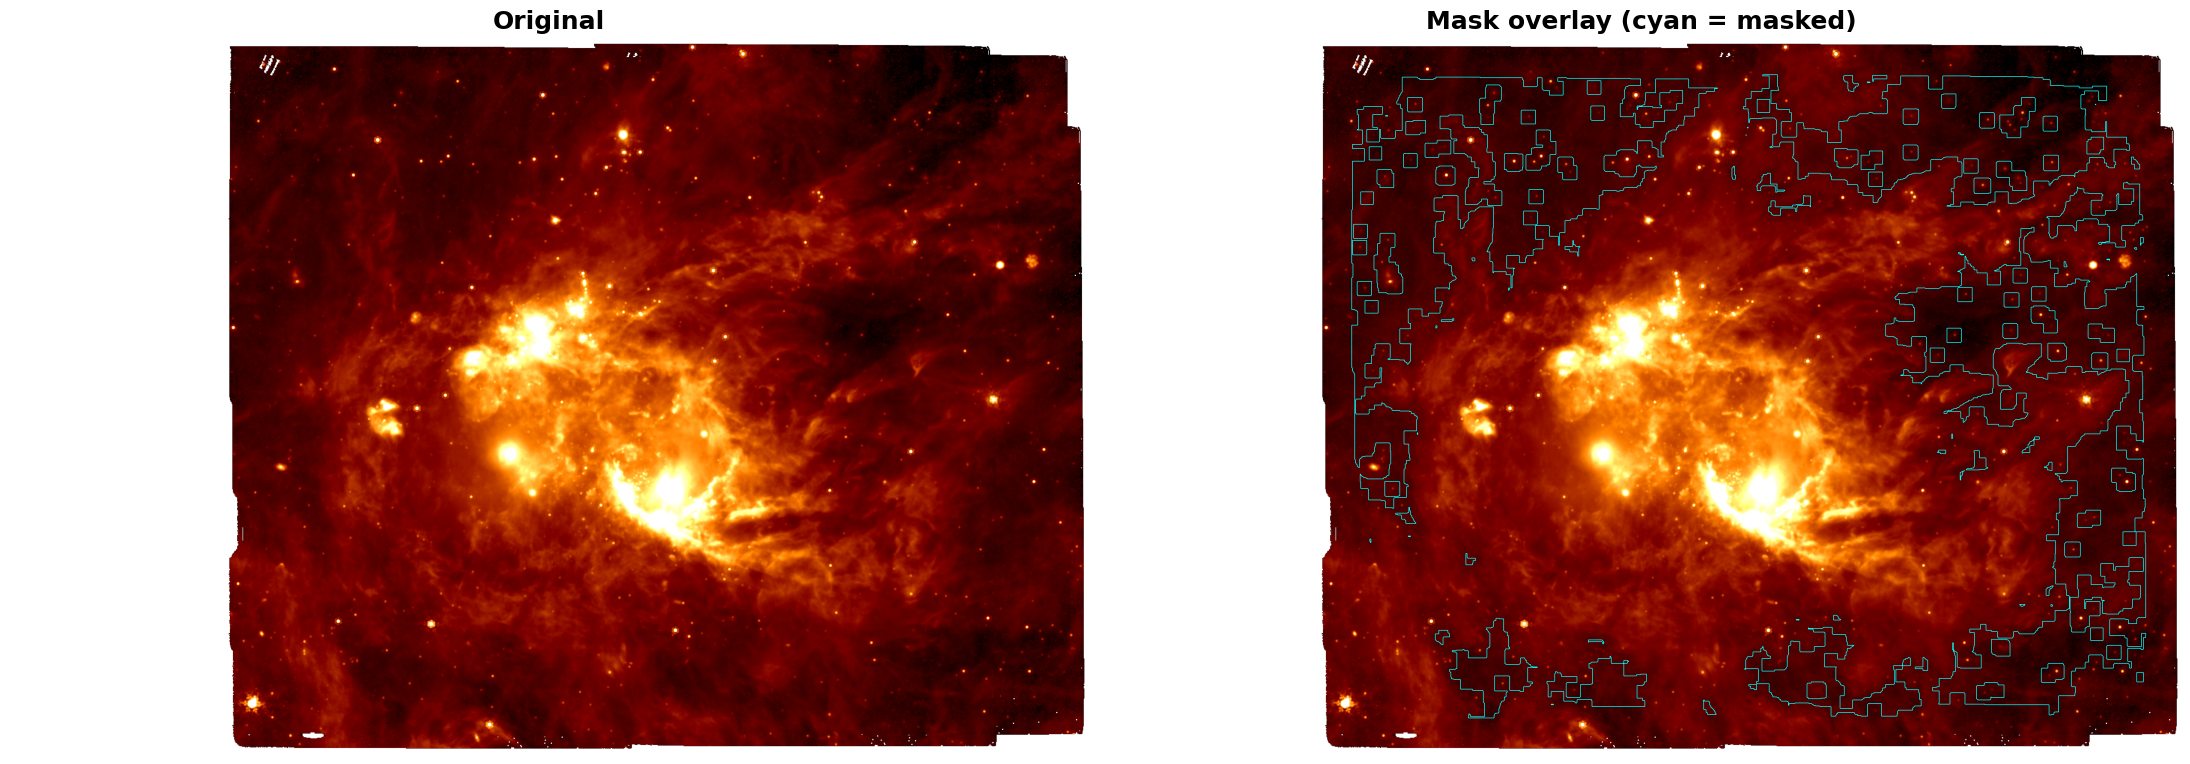

Check that bright sources are masked and the smooth background is unmasked.
Adjust SIGMA_UPPER or GROW_NPIX if needed.


In [7]:
# Visualize the mask
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10), facecolor='white')

norm = simple_norm(data, 'sqrt', percent=99)
ax1.imshow(data, cmap=CMAP, origin='lower', norm=norm)
ax1.set_title('Original', fontsize=18, fontweight='bold', pad=10)
ax1.axis('off')

ax2.imshow(data, cmap=CMAP, origin='lower', norm=norm)
ax2.contour(mask.astype(float), levels=[0.5], colors='cyan', linewidths=0.5)
ax2.set_title('Mask overlay (cyan = masked)', fontsize=18, fontweight='bold', pad=10)
ax2.axis('off')

plt.tight_layout()
plt.show()

print('Check that bright sources are masked and the smooth background is unmasked.')
print('Adjust SIGMA_UPPER or GROW_NPIX if needed.')

## 5. Fit 2D Polynomial

- Degree 2 (quadratic): 6 terms — `1, x, y, x², xy, y²`
- Degree 3 (cubic): 10 terms — adds `x³, x²y, xy², y³`

In [8]:
bg_model, coeffs = fit_2d_polynomial(data, mask, degree=POLY_DEGREE)

  Polynomial degree 2: 6 terms
  Fitting to 339513 unmasked pixels
  Coefficients:
    x^0 * y^0: 1.201152e+01
    x^1 * y^0: 1.175547e-02
    x^2 * y^0: -1.260635e-01
    x^0 * y^1: -4.651635e-02
    x^1 * y^1: 7.489996e-03
    x^0 * y^2: -7.473667e-02
  Residuals (unmasked): mean = -1.915391e-14, std = 7.763918e-02


## 6. Inspect the Background Model

Check that the polynomial surface is smooth — no ringing or sharp features.

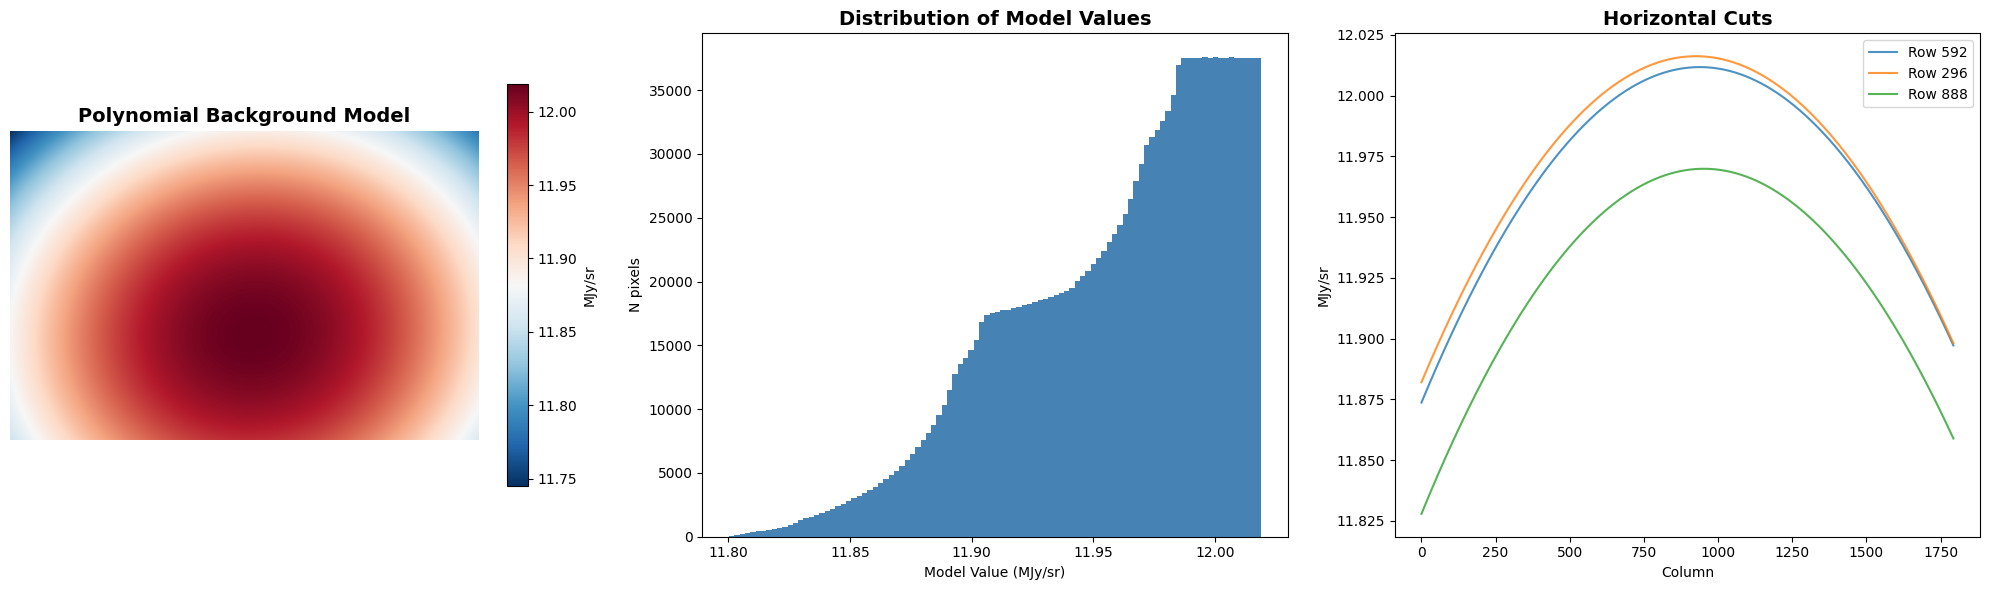

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='white')

# Background model
im = axes[0].imshow(bg_model, origin='lower', cmap='RdBu_r')
axes[0].set_title('Polynomial Background Model', fontsize=14, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], shrink=0.8, label='MJy/sr')

# Histogram
axes[1].hist(bg_model[~np.isnan(data)].ravel(), bins=100, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Model Value (MJy/sr)')
axes[1].set_ylabel('N pixels')
axes[1].set_title('Distribution of Model Values', fontsize=14, fontweight='bold')

# 1D cuts
ny, nx = bg_model.shape
axes[2].plot(bg_model[ny//2, :], label=f'Row {ny//2}', alpha=0.8)
axes[2].plot(bg_model[ny//4, :], label=f'Row {ny//4}', alpha=0.8)
axes[2].plot(bg_model[3*ny//4, :], label=f'Row {3*ny//4}', alpha=0.8)
axes[2].set_xlabel('Column')
axes[2].set_ylabel('MJy/sr')
axes[2].set_title('Horizontal Cuts', fontsize=14, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Subtract

In [10]:
# Subtract
data_sub = data - bg_model
data_sub[np.isnan(data)] = np.nan

# Stats on background region
good_sub = ~np.isnan(data_sub) & ~mask
print(f'Background after subtraction:')
print(f'  mean = {np.nanmean(data_sub[good_sub]):.6e}')
print(f'  std  = {np.nanstd(data_sub[good_sub]):.6e}')
print(f'  (mean should be ~0)')

Background after subtraction:
  mean = -1.915391e-14
  std  = 7.763918e-02
  (mean should be ~0)


## 8. Before / After Comparison

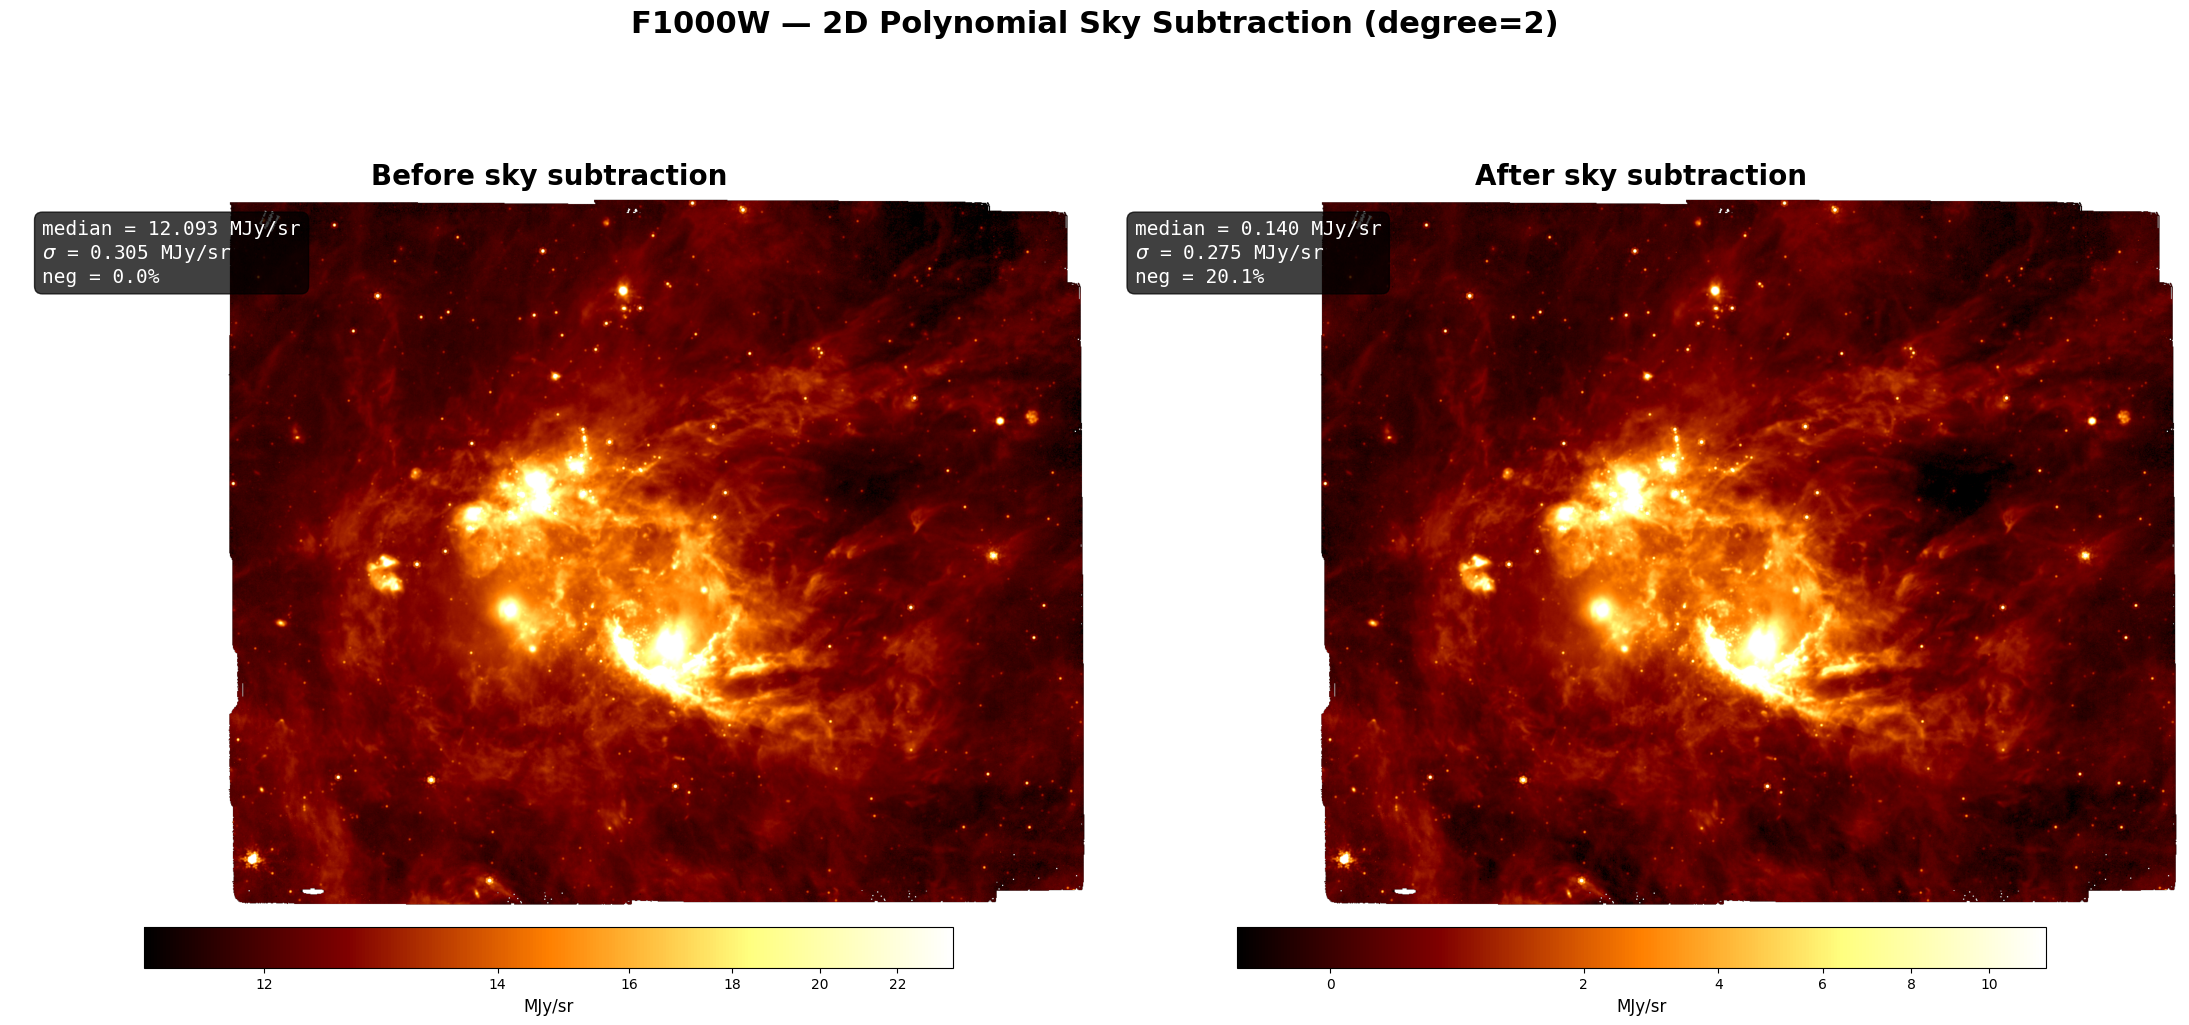

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10), facecolor='white')

# Before
norm_before = simple_norm(data, 'sqrt', percent=99)
im1 = ax1.imshow(data, cmap=CMAP, origin='lower', norm=norm_before)
ax1.set_title('Before sky subtraction', fontsize=20, fontweight='bold', pad=10)
ax1.axis('off')
m_before = get_stats(data)
ax1.text(0.03, 0.97, stats_label(*m_before),
         transform=ax1.transAxes, fontsize=14, va='top',
         color='white', family='monospace',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.75))
cb1 = plt.colorbar(im1, ax=ax1, orientation='horizontal',
                   fraction=0.046, pad=0.02, shrink=0.85)
cb1.set_label('MJy/sr', fontsize=12)

# After
norm_after = simple_norm(data_sub, 'sqrt', percent=99)
im2 = ax2.imshow(data_sub, cmap=CMAP, origin='lower', norm=norm_after)
ax2.set_title('After sky subtraction', fontsize=20, fontweight='bold', pad=10)
ax2.axis('off')
m_after = get_stats(data_sub)
ax2.text(0.03, 0.97, stats_label(*m_after),
         transform=ax2.transAxes, fontsize=14, va='top',
         color='white', family='monospace',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.75))
cb2 = plt.colorbar(im2, ax=ax2, orientation='horizontal',
                   fraction=0.046, pad=0.02, shrink=0.85)
cb2.set_label('MJy/sr', fontsize=12)

plt.suptitle(f'{FILT} — 2D Polynomial Sky Subtraction (degree={POLY_DEGREE})',
             fontsize=22, fontweight='bold', y=1.02)
plt.subplots_adjust(wspace=0.08)
plt.tight_layout()
fig.savefig(f"{fig_dir}/{FILT}_skysub_comparison.png", dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
plt.show()

## 9. Save

In [12]:
# Generate output filename
if OUTPUT_FILE is None:
    base, ext = os.path.splitext(INPUT_FILE)
    OUTPUT_FILE = f'{base}_skysub{ext}'

# Save with model and mask as extra extensions
hdul_out = fits.open(INPUT_FILE)
sci_idx = [h.name for h in hdul_out].index('SCI') if 'SCI' in [h.name for h in hdul_out] else 0

hdul_out[sci_idx].data = data_sub
hdul_out[sci_idx].header['HISTORY'] = f'Sky subtracted: 2D polynomial degree {POLY_DEGREE}'
hdul_out[sci_idx].header['HISTORY'] = f'Sigma clip = {SIGMA_UPPER}, grow = {GROW_NPIX} px'
hdul_out[sci_idx].header['SKYPOLY'] = (POLY_DEGREE, 'Sky polynomial degree')

if SEGM_FILE and os.path.exists(SEGM_FILE):
    hdul_out[sci_idx].header['HISTORY'] = f'Segmentation mask: {os.path.basename(SEGM_FILE)}'

bg_hdu = fits.ImageHDU(data=bg_model, header=header, name='SKYMODEL')
bg_hdu.header['COMMENT'] = 'Fitted 2D polynomial sky model'
hdul_out.append(bg_hdu)

mask_hdu = fits.ImageHDU(data=mask.astype(np.uint8), header=header, name='SKYMASK')
mask_hdu.header['COMMENT'] = 'Source mask used for sky fit (1=masked)'
hdul_out.append(mask_hdu)

hdul_out.writeto(OUTPUT_FILE, overwrite=True)
hdul_out.close()

print(f'Saved: {OUTPUT_FILE}')
print(f'Extensions: SCI (subtracted), SKYMODEL (polynomial surface), SKYMASK (source mask)')

Saved: /Users/melyajou/SMC_GO5952/miri/F1000W/stage3/miri_F1000W_final_i2d_skysub.fits
Extensions: SCI (subtracted), SKYMODEL (polynomial surface), SKYMASK (source mask)


## 10. Background Uncertainties

Three components:
1. **Pixel noise** (random) — σ of background pixels after subtraction
2. **Background level** (systematic) — dispersion among the GO-3429 background observations
3. **Polynomial bias** (systematic) — residual median of background pixels after fit

In [13]:
# 1. Pixel noise
pixel_noise = np.nanstd(data_sub[good_sub])

# 2. Background level uncertainty (only if Clark background was used)
bkg_uncertainty = np.nan
if 'BKG_BASE' in dir():
    bkg_cals = sorted(glob.glob(f"{BKG_BASE}/jw03429*/jw*_cal.fits"))
    if len(bkg_cals) > 1:
        bkg_medians = []
        for f in bkg_cals:
            dm = datamodels.open(f)
            _, med, _ = sigma_clipped_stats(dm.data, sigma=3)
            bkg_medians.append(med)
            dm.close()
        bkg_uncertainty = np.std(bkg_medians)

# 3. Polynomial residual bias
poly_bias = np.abs(np.nanmedian(data_sub[good_sub]))

print(f"Pixel noise (random):          {pixel_noise:.3f} MJy/sr")
if np.isfinite(bkg_uncertainty):
    print(f"Background level (systematic): {bkg_uncertainty:.3f} MJy/sr")
else:
    print(f"Background level (systematic): N/A (no dedicated background field)")
print(f"Polynomial bias (systematic):  {poly_bias:.3f} MJy/sr")

Pixel noise (random):          0.078 MJy/sr
Background level (systematic): N/A (no dedicated background field)
Polynomial bias (systematic):  0.005 MJy/sr


## 11. Summary

In [14]:
line = '=' * 50
print(line)
print(f'  {FILT} — 2D Polynomial Sky Subtraction')
print(line)
print()
print(f'  Background (after subtraction):')
print(f'    mean = {np.nanmean(data_sub[good_sub]):.6e}')
print(f'    std  = {np.nanstd(data_sub[good_sub]):.3f} MJy/sr')
print()
print(f'  Uncertainties:')
print(f'    Pixel noise (random):          {pixel_noise:.3f} MJy/sr')
if np.isfinite(bkg_uncertainty):
    print(f'    Background level (systematic): {bkg_uncertainty:.3f} MJy/sr')
else:
    print(f'    Background level (systematic): N/A')
print(f'    Polynomial bias (systematic):  {poly_bias:.3f} MJy/sr')
print()
print(f'  Settings:')
print(f'    Polynomial degree:  {POLY_DEGREE}')
print(f'    Sigma clipping:     {SIGMA_UPPER}σ')
print(f'    Mask growth:        {GROW_NPIX} px')
print(f'    Edge crop:          {EDGE_CROP} px')
print(f'    Segmentation map:   {os.path.basename(SEGM_FILE) if SEGM_FILE else "None"}')
print()
print(f'  Output: {os.path.basename(OUTPUT_FILE)}')
print(line)

  F1000W — 2D Polynomial Sky Subtraction

  Background (after subtraction):
    mean = -1.915391e-14
    std  = 0.078 MJy/sr

  Uncertainties:
    Pixel noise (random):          0.078 MJy/sr
    Background level (systematic): N/A
    Polynomial bias (systematic):  0.005 MJy/sr

  Settings:
    Polynomial degree:  2
    Sigma clipping:     2σ
    Mask growth:        10 px
    Edge crop:          50 px
    Segmentation map:   miri_F1000W_final_segm.fits

  Output: miri_F1000W_final_i2d_skysub.fits
